In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual theme
sns.set_theme(style="whitegrid")

# Load dataset
df = pd.read_csv('Task 3 and 4_Loan_Data.csv')

# Pre-aggregate data by FICO score to speed up the Dynamic Programming algorithm
fico_counts = df.groupby('fico_score')['default'].agg(['count', 'sum']).rename(columns={'count': 'n', 'sum': 'k'}).reset_index()

# Align everything to a full standard FICO range from 300 to 850
min_fico, max_fico = 300, 850
fico_range_df = pd.DataFrame({'fico': range(min_fico, max_fico + 1)})
fico_full = fico_range_df.merge(fico_counts, left_on='fico', right_on='fico_score', how='left').fillna(0)

n_arr = fico_full['n'].values
k_arr = fico_full['k'].values
N = len(n_arr) # 551 distinct score levels

In [5]:
# Function to calculate log-likelihood for a given bucket configuration
def calculate_bucket_ll(n, k):
    if n == 0:
        return 0.0
    p = k / n
    if p == 0 or p == 1:
        return 0.0  # limit behavior as p -> 0 or 1
    return k * np.log(p) + (n - k) * np.log(1 - p)

print("Precomputing log-likelihoods for all combinations...")
# Prefix sums for fast retrieval
cum_n = np.zeros(N + 1)
cum_k = np.zeros(N + 1)
for i in range(N):
    cum_n[i+1] = cum_n[i] + n_arr[i]
    cum_k[i+1] = cum_k[i] + k_arr[i]

# LL[i, j] holds the log-likelihood for a bucket ranging from index i to j
LL = np.zeros((N, N))
for i in range(N):
    for j in range(i, N):
        n_val = cum_n[j+1] - cum_n[i]
        k_val = cum_k[j+1] - cum_k[i]
        LL[i, j] = calculate_bucket_ll(n_val, k_val)
print("Log-Likelihood Matrix Precomputed Successfully!")

Precomputing log-likelihoods for all combinations...
Log-Likelihood Matrix Precomputed Successfully!


In [7]:
num_buckets = 5  # Modify this value to generate more or fewer ratings buckets

# dp[b, i] stores max log-likelihood for dividing indices 0 to i into b buckets
dp = np.full((num_buckets + 1, N), -np.inf)
parent = np.full((num_buckets + 1, N), -1, dtype=int)

# Base case: 1 bucket covering indices 0 to i
for i in range(N):
    dp[1, i] = LL[0, i]

# Fill the DP table
for b in range(2, num_buckets + 1):
    for i in range(b - 1, N):
        best_val = -np.inf
        best_j = -1
        for j in range(b - 1, i + 1):
            val = dp[b-1, j-1] + LL[j, i]
            if val > best_val:
                best_val = val
                best_j = j
        dp[b, i] = best_val
        parent[b, i] = best_j

# Backtrack to reconstruct the optimal bucket boundaries
boundaries = []
curr_i = N - 1
for b in range(num_buckets, 0, -1):
    start_idx = parent[b, curr_i]
    if b == 1:
        start_idx = 0
    boundaries.append((start_idx + min_fico, curr_i + min_fico))
    curr_i = start_idx - 1

boundaries.reverse()

In [8]:
# Construct and view the rating map mapping
rating_data = []
# Standard banking ratings usually mean: lower rating digit = lower risk
# So we reverse the mapping order so Rating 1 has the best (highest) FICO scores
for idx, (low, high) in enumerate(reversed(boundaries)):
    bucket_df = df[(df['fico_score'] >= low) & (df['fico_score'] <= high)]
    n_val = bucket_df.shape[0]
    k_val = bucket_df['default'].sum()
    p_val = k_val / n_val if n_val > 0 else 0
    
    rating_data.append({
        'Rating': idx + 1,
        'FICO Lower Bound': low,
        'FICO Upper Bound': high,
        'Total Borrowers': n_val,
        'Defaults': k_val,
        'Observed PD': f"{p_val:.2%}"
    })

rating_map_df = pd.DataFrame(rating_data)
print("=== OPTIMAL FICO RATING MAP ===")
display(rating_map_df)

=== OPTIMAL FICO RATING MAP ===


,Rating,FICO Lower Bound,FICO Upper Bound,Total Borrowers,Defaults,Observed PD
0,1,697,850,1657,77,4.65%
1,2,641,696,3197,336,10.51%
2,3,581,640,3438,703,20.45%
3,4,521,580,1407,536,38.10%
4,5,300,520,301,199,66.11%


C:\Users\abuha\AppData\Local\Temp\ipykernel_2956\1980708858.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Rating', y='PD_float', data=plot_df, palette='RdYlGn_r')


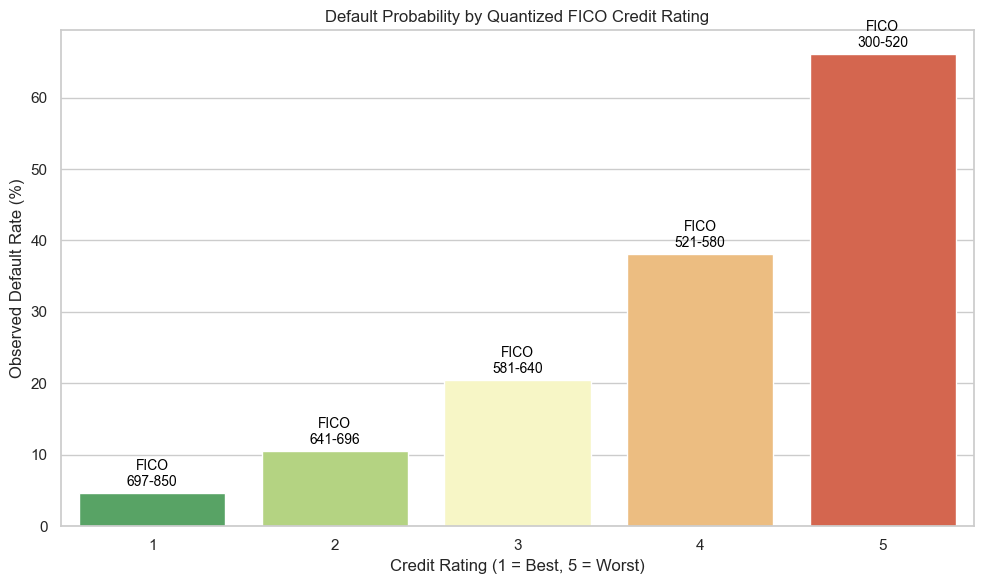

In [9]:
plt.figure(figsize=(10, 6))
# Convert Observed PD string back to a float for plotting
plot_df = rating_map_df.copy()
plot_df['PD_float'] = plot_df['Observed PD'].str.rstrip('%').astype(float)

sns.barplot(x='Rating', y='PD_float', data=plot_df, palette='RdYlGn_r')
plt.ylabel('Observed Default Rate (%)')
plt.xlabel('Credit Rating (1 = Best, 5 = Worst)')
plt.title('Default Probability by Quantized FICO Credit Rating')
for index, row in plot_df.iterrows():
    plt.text(index, row['PD_float'] + 1, f"FICO\n{row['FICO Lower Bound']}-{row['FICO Upper Bound']}", 
             color='black', ha="center", fontsize=10)
plt.tight_layout()
plt.show()